In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Device:",device)

Using Device: cuda


In [3]:
df = pd.read_csv("/content/energy-history-2026-02-25.csv")
df.head()

,Date,Time,Room,Temperature (°C),Humidity (%),Light (lux),Motion
0,23/2/2026,08:32:02,Bedroom,26.9,82.4,6.15,Not Detected
1,23/2/2026,08:31:54,Living Room,27.0,82.5,10.09,Not Detected
2,23/2/2026,08:30:59,Living Room,27.0,82.5,10.26,Not Detected
3,23/2/2026,08:30:57,Bedroom,26.9,82.4,6.37,Not Detected
4,23/2/2026,08:27:59,Living Room,27.0,82.6,10.16,Not Detected


In [4]:
df.columns = df.columns.str.strip().str.lower()
df["timestamp"] = pd.to_datetime(df["date"]+" "+df["time"])
df = df.sort_values("timestamp")
room_encoder = LabelEncoder()
df["room"] = room_encoder.fit_transform(df["room"])
df["motion"] = df["motion"].apply(lambda x:1 if "detected" in x.lower() else 0)

/tmp/ipython-input-331/729036028.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(df["date"]+" "+df["time"])


In [5]:
features = [
    "temperature (°c)",
    "humidity (%)",
    "light (lux)",
    "room",
    "motion"
]
df_model = df[features]
df_model.head()

,temperature (°c),humidity (%),light (lux),room,motion
1513,27.7,72.4,85.93,0,1
1512,26.8,76.4,85.89,1,1
1511,27.3,72.3,85.96,0,1
1510,26.8,75.3,85.91,1,1
1509,27.2,72.7,85.93,0,1


In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)
scaled_data.shape

(1514, 5)

In [7]:
def create_sequences(data, seq_len=60):
  X, y = [], []
  for i in range(len(data)-seq_len):
    X.append(data[i:i+seq_len])
    y.append(data[i+seq_len])
  return np.array(X), np.array(y)
SEQ_LEN = 60
X, y = create_sequences(scaled_data, SEQ_LEN)
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)
print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: torch.Size([1454, 60, 5])
Output Shape: torch.Size([1454, 5])


In [8]:
import torch.nn as nn
class MultiFeatureLSTM(nn.Module):
  def __init__(self, input_size=5, hidden_size=128, num_layers=2):
    super().__init__()
    self.lstm = nn.LSTM(
        input_size,
        hidden_size,
        num_layers,
        batch_first=True
    )
    self.fc = nn.Linear(hidden_size, input_size)
  def forward(self,x):
    out, _= self.lstm(x)
    out = out[:,-1,:]
    out = self.fc(out)
    return out
model = MultiFeatureLSTM().to(device)
print(model)

MultiFeatureLSTM(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 100
BATCH_SIZE = 64
for epoch in range(EPOCHS):
  perm = torch.randperm(X.size(0))
  total_loss = 0
  for i in range(0, X.size(0), BATCH_SIZE):
    idx = perm[i:i+BATCH_SIZE]
    x_batch = X[idx]
    y_batch = y[idx]
    optimizer.zero_grad()
    y_pred = model(x_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.6f}")

Epoch 1/100, Loss: 3.761008
Epoch 2/100, Loss: 1.918448
Epoch 3/100, Loss: 1.512264
Epoch 4/100, Loss: 1.429692
Epoch 5/100, Loss: 1.389807
Epoch 6/100, Loss: 1.372130
Epoch 7/100, Loss: 1.344910
Epoch 8/100, Loss: 1.290674
Epoch 9/100, Loss: 1.184849
Epoch 10/100, Loss: 0.923900
Epoch 11/100, Loss: 0.772612
Epoch 12/100, Loss: 0.682333
Epoch 13/100, Loss: 0.647005
Epoch 14/100, Loss: 0.563247
Epoch 15/100, Loss: 0.543072
Epoch 16/100, Loss: 0.530294
Epoch 17/100, Loss: 0.492319
Epoch 18/100, Loss: 0.485309
Epoch 19/100, Loss: 0.472358
Epoch 20/100, Loss: 0.468152
Epoch 21/100, Loss: 0.462985
Epoch 22/100, Loss: 0.465707
Epoch 23/100, Loss: 0.460925
Epoch 24/100, Loss: 0.452144
Epoch 25/100, Loss: 0.445419
Epoch 26/100, Loss: 0.440165
Epoch 27/100, Loss: 0.439404
Epoch 28/100, Loss: 0.440737
Epoch 29/100, Loss: 0.440040
Epoch 30/100, Loss: 0.432893
Epoch 31/100, Loss: 0.431072
Epoch 32/100, Loss: 0.431162
Epoch 33/100, Loss: 0.428898
Epoch 34/100, Loss: 0.430735
Epoch 35/100, Loss: 0.4

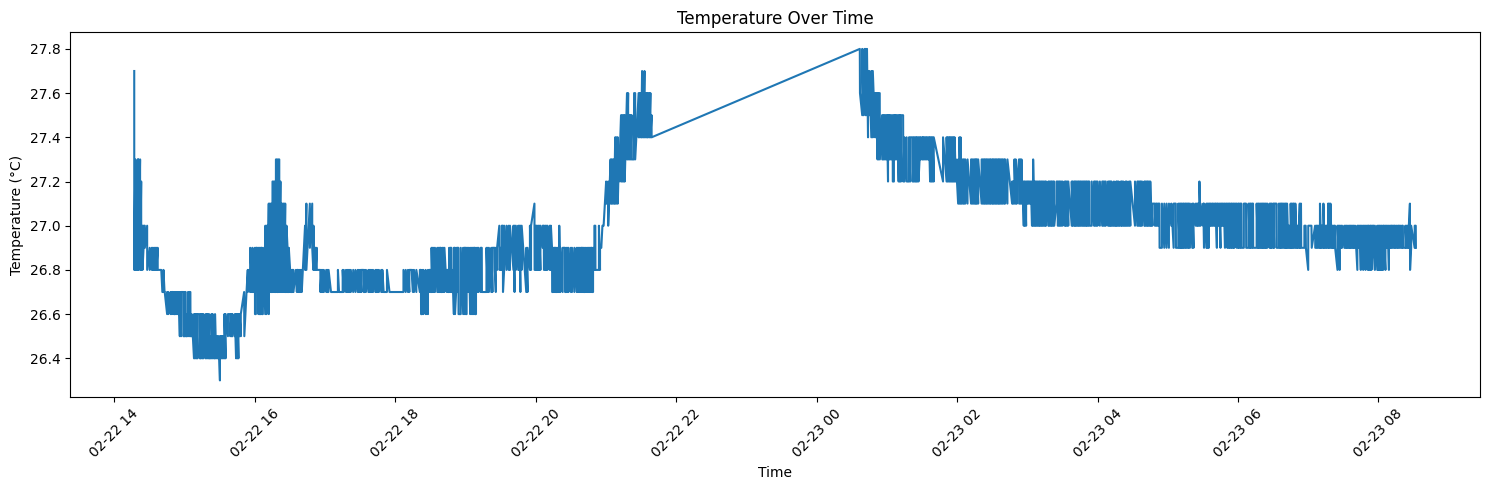

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["temperature (°c)"])
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

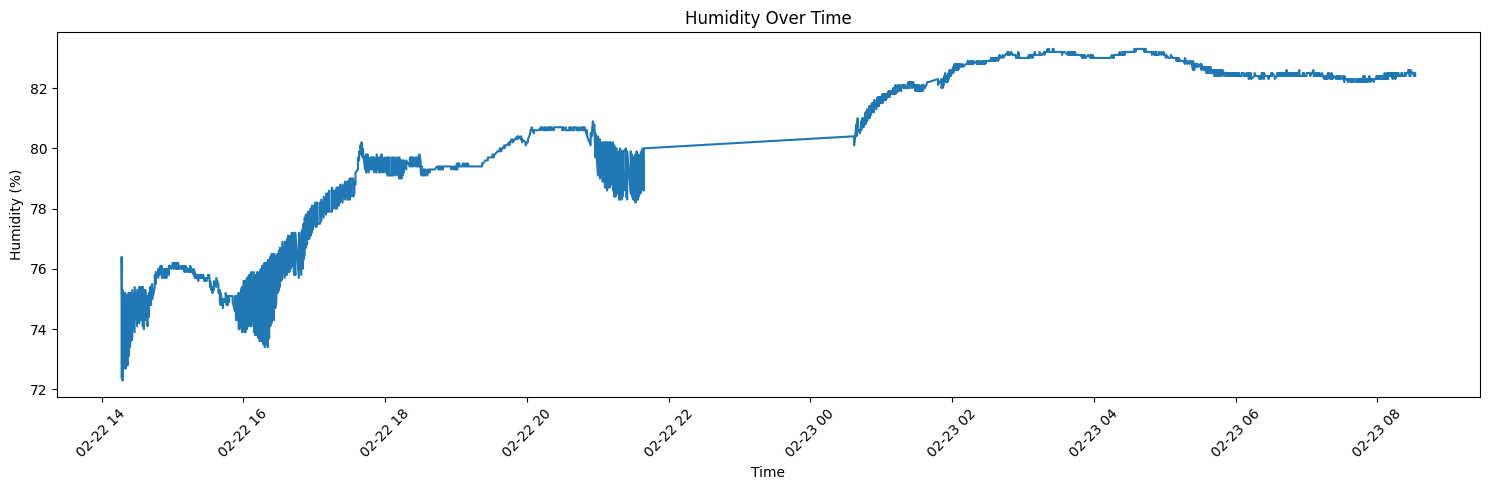

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["humidity (%)"])
plt.title("Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

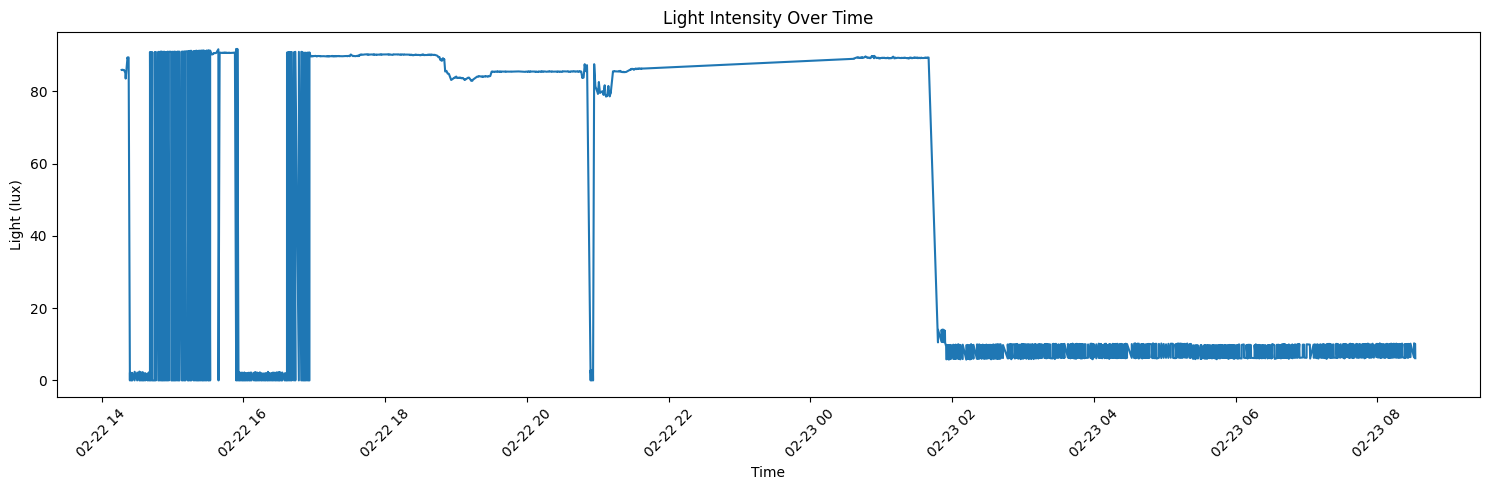

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["light (lux)"])
plt.title("Light Intensity Over Time")
plt.xlabel("Time")
plt.ylabel("Light (lux)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

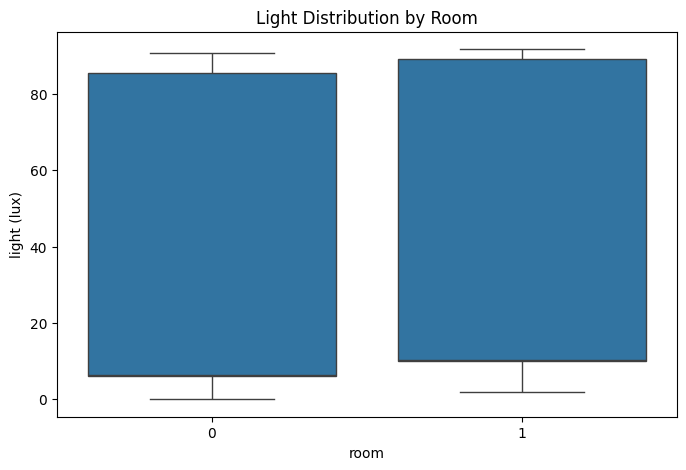

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="room", y="light (lux)", data=df)
plt.title("Light Distribution by Room")
plt.show()

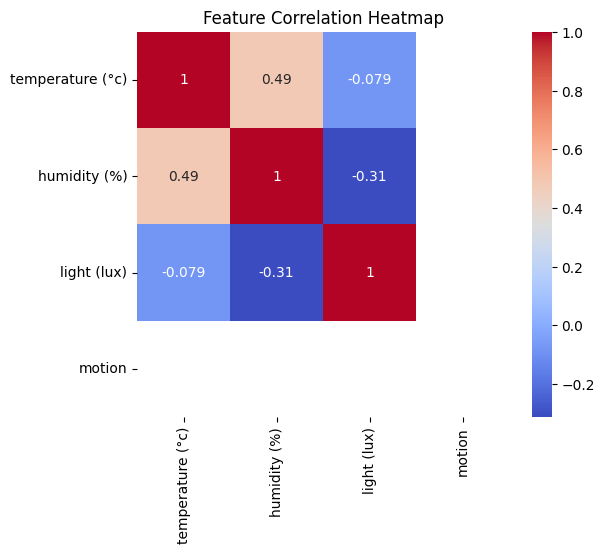

In [14]:
numeric_df = df[[
    "temperature (°c)",
    "humidity (%)",
    "light (lux)",
    "motion"
]]

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

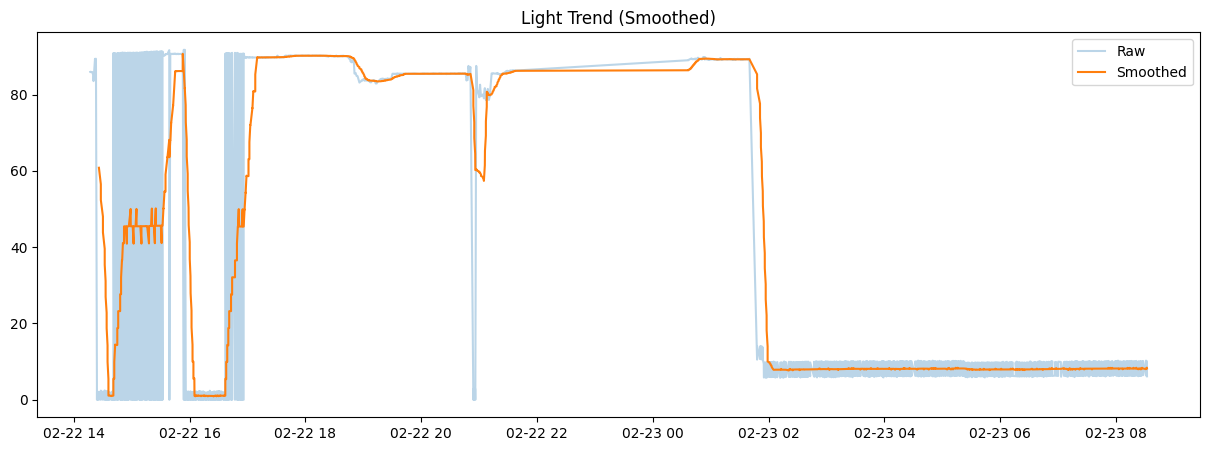

In [15]:
df.set_index("timestamp", inplace=True)

df["light_rolling"] = df["light (lux)"].rolling(window=20).mean()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["light (lux)"], alpha=0.3, label="Raw")
plt.plot(df.index, df["light_rolling"], label="Smoothed")
plt.title("Light Trend (Smoothed)")
plt.legend()
plt.show()

Mean Squared Error on training data: 0.014364


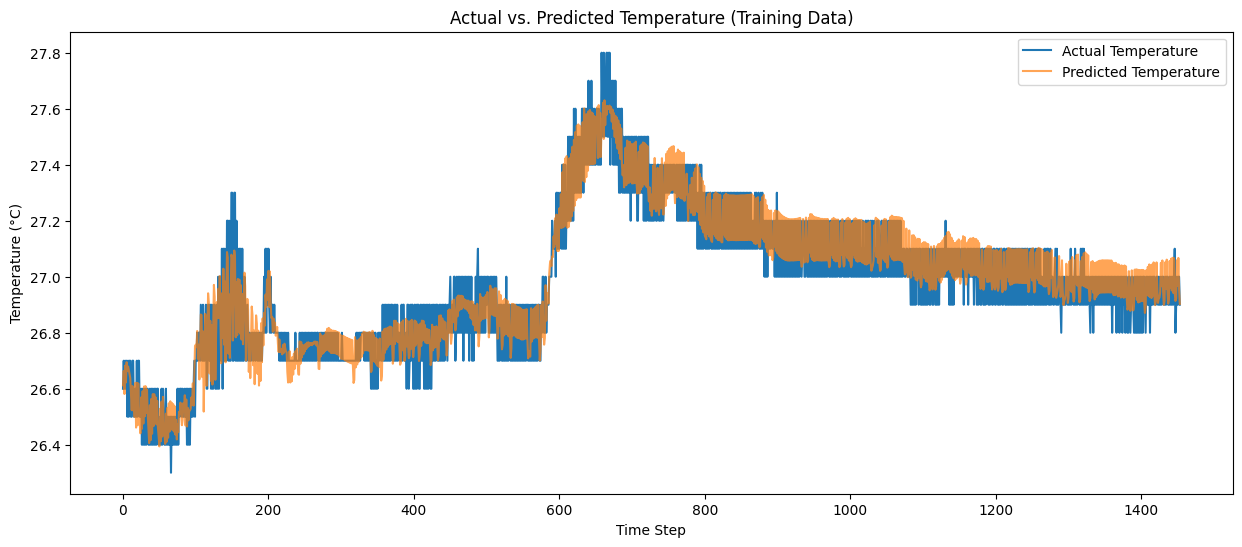

In [16]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X)
    loss = criterion(y_pred_scaled, y)
    print(f"Mean Squared Error on training data: {loss.item():.6f}")
y_pred = scaler.inverse_transform(y_pred_scaled.cpu().numpy())
y_actual = scaler.inverse_transform(y.cpu().numpy())
temp_idx = features.index('temperature (°c)')
plt.figure(figsize=(15, 6))
plt.plot(y_actual[:, temp_idx], label='Actual Temperature')
plt.plot(y_pred[:, temp_idx], label='Predicted Temperature', alpha=0.7)
plt.title('Actual vs. Predicted Temperature (Training Data)')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [17]:
torch.save(model.state_dict(), "iot_lstm_model.pt")
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(room_encoder, "room_encoder.pkl")

['room_encoder.pkl']